# 4c — Pavement Temperatures Under Climate Change

## Purpose
Process climate-atlas temperature rasters for Serbia, calculate current and future maximum pavement temperatures, apply urban-heat-island (UHI) offsets for urban areas, and assign resulting temperatures to the national road network. All vector outputs saved to parquet + ArcGIS File Geodatabase in EPSG:6316.

## Inputs
| File | Description |
|------|-------------|
| `input_files/ne_10m_admin_0_countries.shp` | Natural Earth country boundaries (Serbia outline) |
| `input_files/Temperatures climate change/TX7D_1961-1990.tif` | Historic 7-day max air temperature (1961–1990) |
| `input_files/Temperatures climate change/TX7D_1991-2020.tif` | Current 7-day max air temperature (1991–2020) |
| `input_files/Temperatures climate change/TPAV_2021-2025.tif` | Current max pavement temperature (2021–2025 avg) |
| `input_files/GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0_R4_C20.tif` | Global degree-of-urbanisation raster (SMOD) |
| `intermediate_results/PERS_directed_final.parquet` | Processed road network |

## Outputs
| File | Description |
|------|-------------|
| `figures/temperature/diff_TX7D_1961-1990_vs_TX7D_1991-2020.png` | 3-panel historic/current/difference air temperature map |
| `figures/temperature/pavement_temperature.png` | Current pavement temperature map |
| `figures/temperature/pavement_temperature_(+_2°c).png` | +2 °C climate-change adjusted pavement temperature |
| `figures/temperature/pavement_temperature_with_urban_heat_islands_under_climate_change.png` | Pavement temperature with UHI (+5 °C urban classes) |
| `intermediate_results/future_pavement_temperatures.tif` | Future UHI-adjusted pavement temperature raster |
| `figures/temperature/road_network_—_pavement_temperature.png` | Road network coloured by current pavement temperature |
| `figures/temperature/road_network_—_pavement_temperature_with_uhi.png` | Road network coloured by future temperature |
| `intermediate_results/parquet/hazard_exposure/road_network_—_pavement_temperature.parquet` | Roads with current max pavement temperature (EPSG:6316) |
| `intermediate_results/parquet/hazard_exposure/road_network_—_pavement_temperature_with_uhi.parquet` | Roads with future max pavement temperature (EPSG:6316) |
| `intermediate_results/database/hazard_exposure/hazard_exposure.gdb` | GDB layers for both road temperature outputs |

## Key Processing Steps
1. **Load Serbia outline** — from local Natural Earth shapefile (avoids URL download); reproject to EPSG:3857
2. **Temperature difference** — load historic and current air-temperature TIFs; compute difference; 3-panel plot
3. **Current pavement temperature** — load pavement TIF; print bin statistics masked to Serbia; plot
4. **+2 °C scenario** — add 2 °C uniform offset; plot
5. **Urban heat island** — reproject SMOD urbanisation raster; apply +5 °C to SMOD classes 22/23/30; save GeoTIFF
6. **UHI-adjusted plot** — plot future pavement temperature with UHI offsets
7. **Assign to roads** — zonal_stats max per road segment for current and UHI scenarios; save parquet+GDB; plot road maps

In [1]:
import sys
import warnings
from pathlib import Path

import geopandas as gpd
import numpy as np

BASE_DIR = Path(r"C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia")
sys.path.append(str(BASE_DIR))

from utils.hazard_functions import (
    apply_urban_heat_island,
    assign_and_plot_road_temperatures,
    clip_roads_by_country,
    load_country_boundaries,
    mask_to_serbia,
    plot_pavement_temperature,
    plot_pavement_temperature_roads_AB,
    plot_temperature_difference,
    read_tif,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [2]:
data_path = BASE_DIR / "input_files"
intermediate_results_path = BASE_DIR / "intermediate_results"
output_folder = BASE_DIR / "figures" / "temperature"
parquet_dir = intermediate_results_path / "parquet" / "hazard_exposure"
gdb_path = intermediate_results_path / "database" / "hazard_exposure" / "hazard_exposure.gdb"
output_crs = "EPSG:6316"

HISTORIC_TIF = data_path / "Temperatures climate change" / "TX7D_1961-1990.tif"
CURRENT_TIF  = data_path / "Temperatures climate change" / "TX7D_1991-2020.tif"
CURRENT_PAV_TEMP_TIF = data_path / "Temperatures climate change" / "TPAV_2021-2025.tif"
DEGREE_OF_URBANIZATION_TIF = data_path / "GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0_R4_C20.tif"

In [3]:
# Load Serbia outline from local shapefile (not URL) to avoid network dependency
world = gpd.read_file(data_path / "ne_10m_admin_0_countries.shp")
country_plot = world.loc[world.SOV_A3 == "SRB"]
serbia_3857 = country_plot.to_crs(3857)
print(f"Loaded Serbia: {len(serbia_3857)} polygon(s)")

# Kosovo road network (shown in grey on the road-network panel of the A/B figure)
_, serbia, kosovo = load_country_boundaries(data_path / "ne_10m_admin_0_countries.shp")
baseline_roads = gpd.read_file(data_path / "Deonice_Februar_2025.shp")
_, kosovo_roads = clip_roads_by_country(baseline_roads, serbia, kosovo)
kosovo_roads_mercator = kosovo_roads.to_crs(3857)

Loaded Serbia: 1 polygon(s)


## Temperature Difference (Historic vs Current)

  Min Δ: 0.9425 °C | Max Δ: 2.4907 °C | Mean Δ: 1.8558 °C


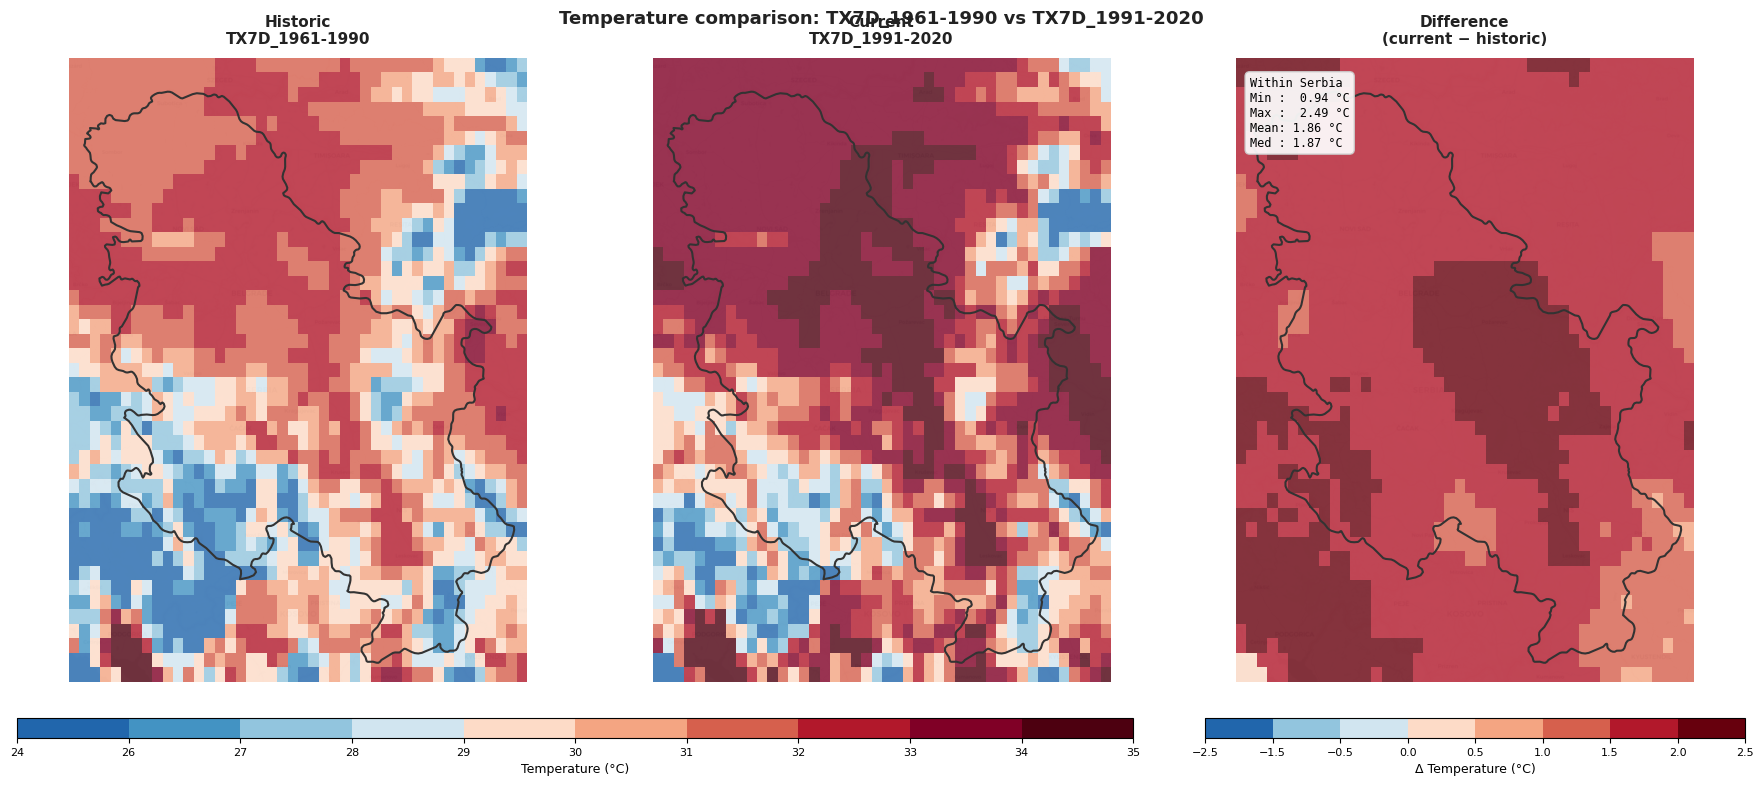

In [4]:
plot_temperature_difference(HISTORIC_TIF, CURRENT_TIF, serbia_3857, output_folder, dpi=300)

In [5]:
data, bounds, crs = read_tif(CURRENT_PAV_TEMP_TIF)

data_serbia = mask_to_serbia(data, bounds, crs, serbia_3857)
valid = data_serbia[~np.isnan(data_serbia)]
print(f"Pavement temp range: {valid.min():.2f} – {valid.max():.2f} °C")

Pavement temp range: 46.97 – 56.95 °C


Bin distribution for: Pavement Temperature
  Bin                Cells  % of total
  ─────────────────────────────────────
  < 50                  56        6.4%
  50 – 53              171       19.4%
  53 – 56              630       71.6%
  56 – 59               23        2.6%
  59 – 62                0        0.0%
  62 – 64                0        0.0%
  > 64                   0        0.0%
  ─────────────────────────────────────
  Total                880      100.0%



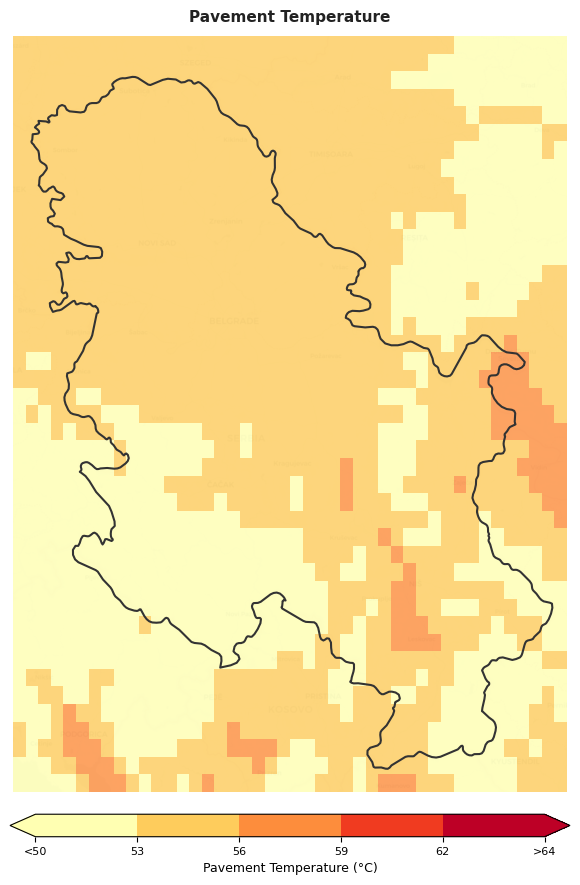

In [6]:
plot_pavement_temperature(data, "Pavement Temperature", output_folder, bounds, crs, serbia_3857, dpi=300)

Bin distribution for: Pavement Temperature (+ 2°C)
  Bin                Cells  % of total
  ─────────────────────────────────────
  < 50                   4        0.5%
  50 – 53               89       10.1%
  53 – 56              247       28.1%
  56 – 59              540       61.4%
  59 – 62                0        0.0%
  62 – 64                0        0.0%
  > 64                   0        0.0%
  ─────────────────────────────────────
  Total                880      100.0%



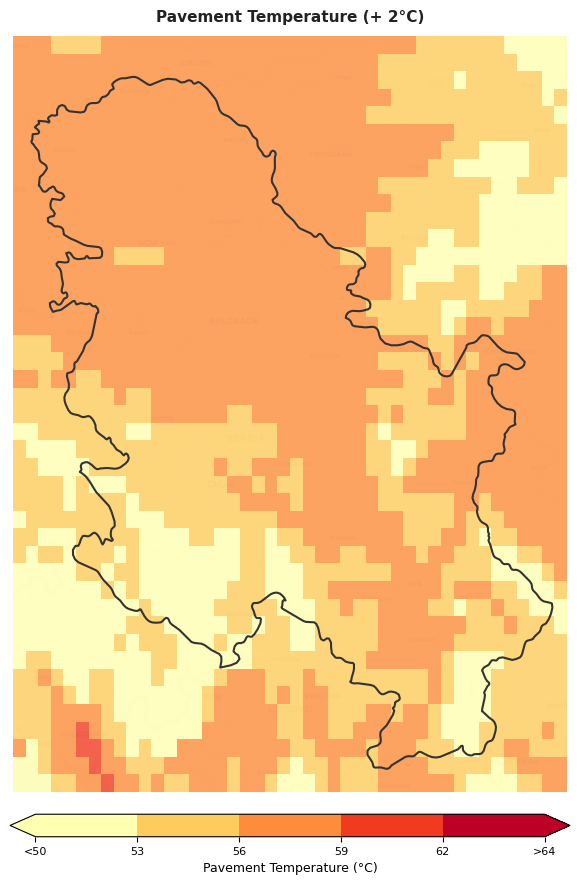

In [7]:
plot_pavement_temperature(data + 2, "Pavement Temperature (+ 2°C)", output_folder, bounds, crs, serbia_3857, dpi=300)

In [8]:
data_uhi = apply_urban_heat_island(
    bounds=bounds,
    degree_of_urbanization_path=DEGREE_OF_URBANIZATION_TIF,
    current_max_pavement_temperature_path=CURRENT_PAV_TEMP_TIF,
    output_tif_path=intermediate_results_path / "future_pavement_temperatures.tif",
)

Climate bounds in Mollweide: (1486807.6856812085, 5022734.234321175, 1922992.22326269, 5491412.46115576)
  Class 30:      724 cells  (+5.0°C)
  Class 23:      515 cells  (+5.0°C)
  Class 22:      200 cells  (+5.0°C)

Output shape: (462, 300) | Min: 43.51 °C | Max: 64.81 °C
Saved UHI raster: C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\future_pavement_temperatures.tif


Bin distribution for: Pavement Temperature with urban heat islands under climate change
  Bin                Cells  % of total
  ─────────────────────────────────────
  < 50                 261        0.4%
  50 – 53            6,429       10.0%
  53 – 56           17,945       28.0%
  56 – 59           38,570       60.2%
  59 – 62              476        0.7%
  62 – 64              365        0.6%
  > 64                   0        0.0%
  ─────────────────────────────────────
  Total             64,046      100.0%



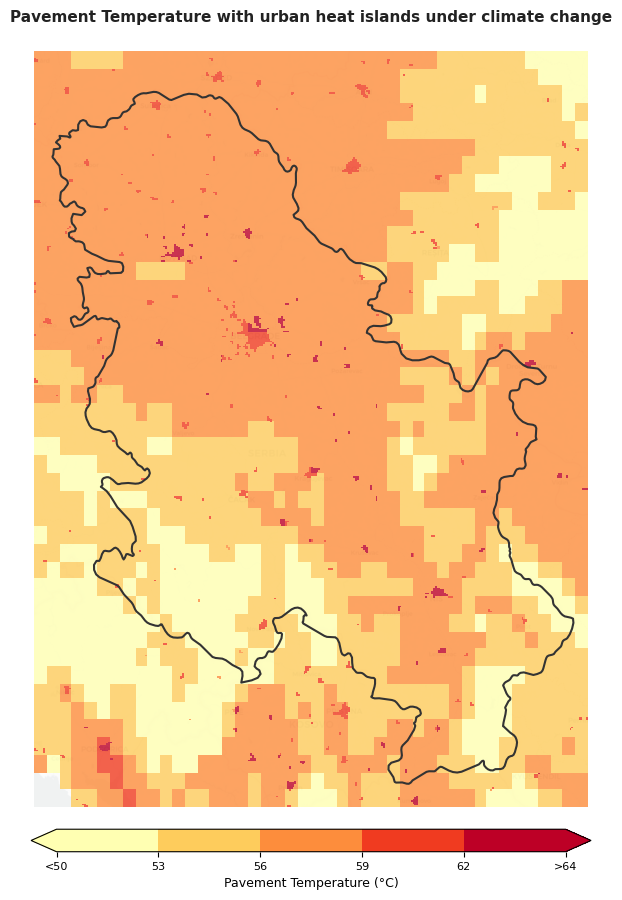

In [9]:
plot_pavement_temperature(
    data_uhi,
    "Pavement Temperature with urban heat islands under climate change",
    output_folder, bounds, crs, serbia_3857, dpi=300,
)

Roads with temperature assigned: 5,547
Roads outside raster extent    : 0
Temperature range              : 48.42 – 56.95 °C

Road segment distribution:
  Bin                Roads  % of total
  ─────────────────────────────────────
  50 – 53              324        5.8%
  53 – 56            4,755       85.7%
  56 – 59              426        7.7%
  59 – 62                0        0.0%
  62 – 64                0        0.0%
  ─────────────────────────────────────
  Total              5,547      100.0%
Saved road_network_—_pavement_temperature -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\hazard_exposure\road_network_—_pavement_temperature.parquet
Saved road_network_—_pavement_temperature -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\database\hazard_exposure\hazard_exposure.gdb (layer 'road_network_—_pavement_temperature')


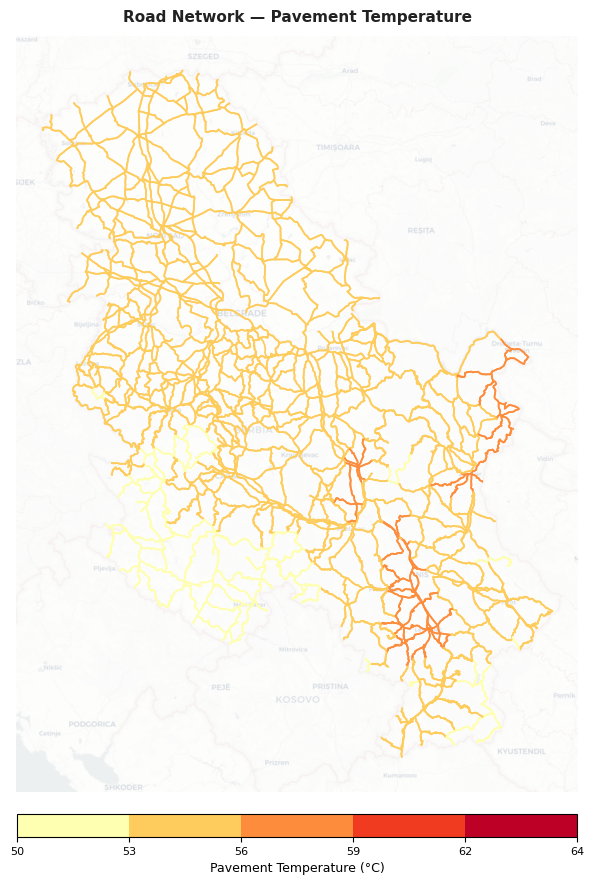

In [10]:
# Current pavement temperatures assigned to road network
assign_and_plot_road_temperatures(
    raster_data=data,
    raster_bounds=bounds,
    raster_crs=crs,
    input_parquet=intermediate_results_path / "PERS_directed_final.parquet",
    parquet_dir=parquet_dir,
    gdb_path=gdb_path,
    output_folder=output_folder,
    title="Road Network — Pavement Temperature",
    output_crs=output_crs,
    dpi=300,
)

Roads with temperature assigned: 5,547
Roads outside raster extent    : 0
Temperature range              : 50.42 – 63.91 °C

Road segment distribution:
  Bin                Roads  % of total
  ─────────────────────────────────────
  50 – 53               64        1.2%
  53 – 56              544        9.8%
  56 – 59            3,997       72.1%
  59 – 62              520        9.4%
  62 – 64              422        7.6%
  ─────────────────────────────────────
  Total              5,547      100.0%
Saved road_network_—_pavement_temperature_with_uhi -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\hazard_exposure\road_network_—_pavement_temperature_with_uhi.parquet
Saved road_network_—_pavement_temperature_with_uhi -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\database\hazard_exposure\hazard_exposure.gdb (layer 'road_network_—_pavement_temperature_with_

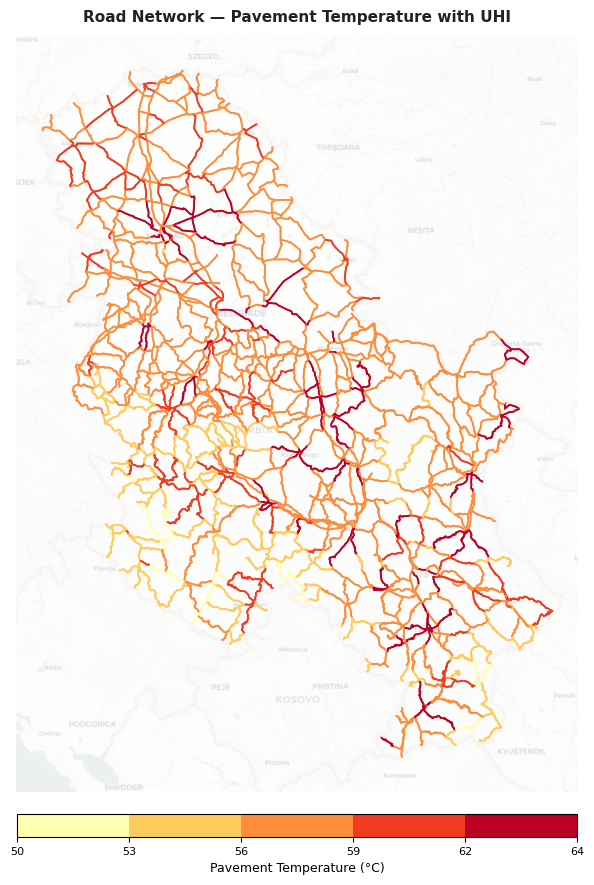

In [11]:
# Future pavement temperatures (UHI + climate change) assigned to road network
assign_and_plot_road_temperatures(
    raster_data=data_uhi,
    raster_bounds=bounds,
    raster_crs=crs,
    input_parquet=intermediate_results_path / "PERS_directed_final.parquet",
    parquet_dir=parquet_dir,
    gdb_path=gdb_path,
    output_folder=output_folder,
    title="Road Network — Pavement Temperature with UHI",
    output_crs=output_crs,
    dpi=300,
)

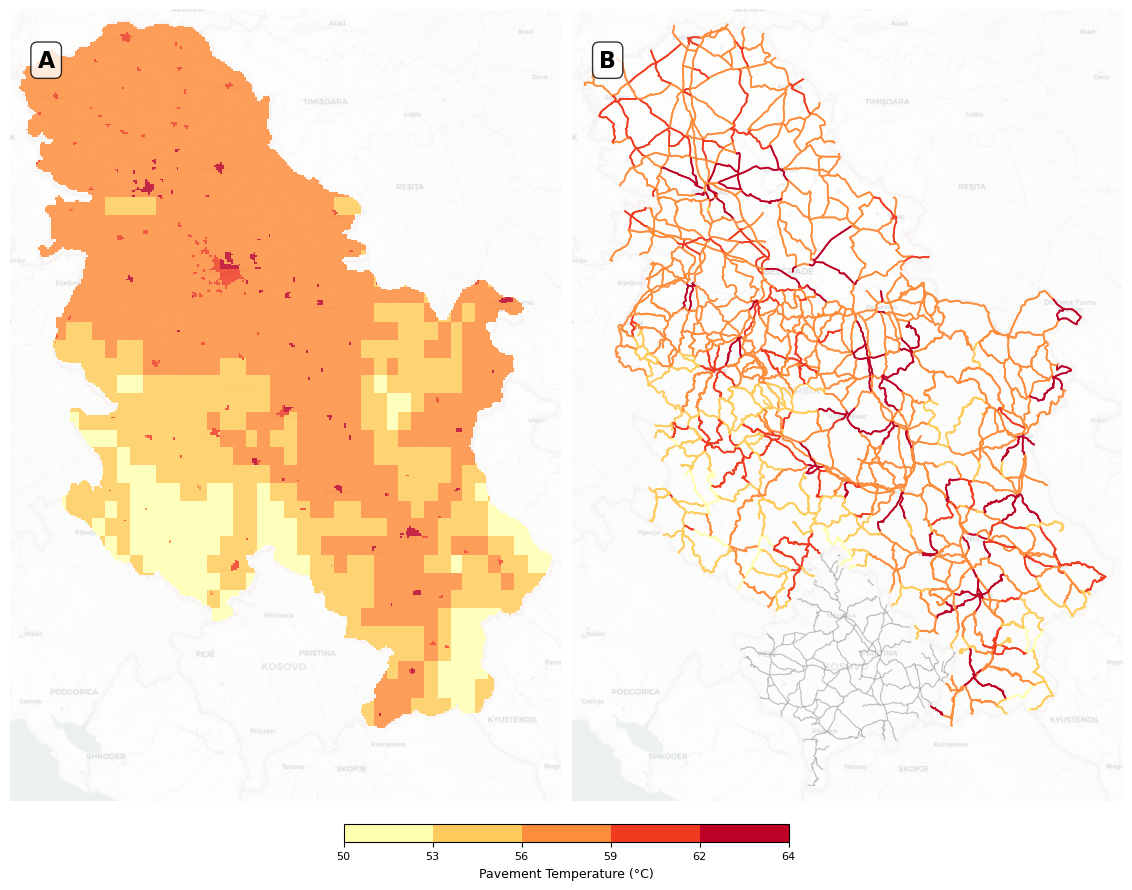

In [12]:
# Combined A/B figure: UHI pavement-temperature raster (A) + road network coloured
# by the same UHI temperatures (B). Serbia-only heat pixels, Kosovo roads in grey.
plot_pavement_temperature_roads_AB(
    raster_data=data_uhi,
    raster_bounds=bounds,
    raster_crs=crs,
    input_parquet=intermediate_results_path / "PERS_directed_final.parquet",
    serbia_3857=serbia_3857,
    kosovo_roads_mercator=kosovo_roads_mercator,
    output_folder=output_folder,
    dpi=300,
)